In [ ]:
#import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load our dataset

df = pd.read_csv("https://raw.githubusercontent.com/nilakshiGogoi/DmartAnalysis/refs/heads/main/Dmart.csv")

In [ ]:
#data preview
df.head()

,Customer ID,Product ID,Order ID,Customer Age,Gender,Product Name,MRP,Discount Price,Category,State,...,Delivery Date,Cancellation Date,Payment Method,Pin Code,Total Order Value,Payment Status,No of Clicks,Year,Month,Shipping Charges
0,YSB75,BW653,479577309,28,Female,Ariel Matic Top Load Liquid Detergent,977.44,909.02,Imported,Andhra Pradesh,...,13-05-2022,NaN,Credit,318324,909.02,Paid,29,2022,May,0
1,FUS93,XV061,634865221,47,Male,VSR Channa Dal,834.09,450.41,Branded,Telangana,...,20-08-2021,NaN,Debit,730162,450.41,Paid,95,2021,August,0
2,AJP28,GF695,113166210,63,Female,Tenali Double Horse Chana Dal,1095.20,1007.58,Branded,Gujarat,...,26-10-2021,NaN,Debit,694091,1007.58,Paid,51,2021,October,0
3,URC55,VM478,740539230,41,Male,Tata Tea,748.16,389.04,Imported,Maharashtra,...,27-08-2021,NaN,Credit,211807,489.04,Pending,12,2021,August,100
4,ZOP23,XD230,156544145,22,Female,VSR Channa Dal,1249.04,911.80,Local,Gujarat,...,10-12-2023,NaN,Credit,78304,1011.8,Paid,26,2023,December,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              25000 non-null  object 
 1   Product ID               25000 non-null  object 
 2   Order ID                 25000 non-null  int64  
 3   Customer Age             25000 non-null  int64  
 4   Gender                   25000 non-null  object 
 5   Product Name             25000 non-null  object 
 6   MRP                      25000 non-null  float64
 7   Discount Price           25000 non-null  float64
 8   Category                 25000 non-null  object 
 9   State                    25000 non-null  object 
 10  City                     25000 non-null  object 
 11  Subscription             25000 non-null  object 
 12  Bill Number              25000 non-null  float64
 13  Time Spent on Website    25000 non-null  float64
 14  Rating                

In [ ]:
#check for column based missing values
df.isna().sum()

,0
Customer ID,0
Product ID,0
Order ID,0
Customer Age,0
Gender,0
Product Name,0
MRP,0
Discount Price,0
Category,0
State,0


In [ ]:
#standardizing the column names
df.columns = df.columns.str.lower().str.replace(" ","_")

In [ ]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges'],
      dtype='object')

Customer insights

In [ ]:
#gender distribution
df["gender"].value_counts()

,count
gender,
Male,14250
Female,10750


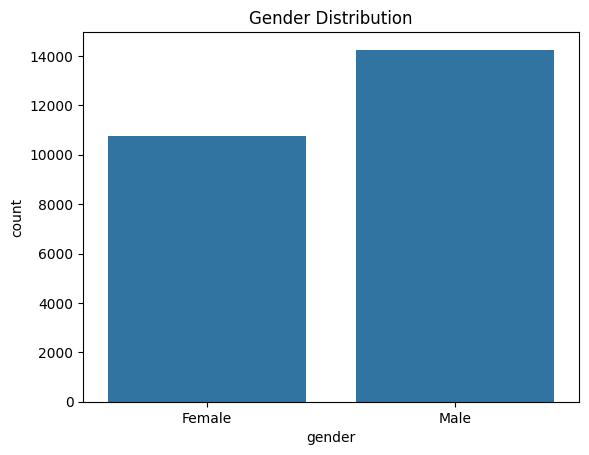

In [ ]:
sns.countplot(x="gender",data=df)
plt.title("Gender Distribution")
plt.show()

Male customers are higher than female customers

In [ ]:
# 0 to 25 years: KidsYA
# 26 to 45 years: Adults
# 46 to 60 years: MiddleAged
# 61 yeARS AND ABOVE 120: Seniors

df["age_group"] = pd.cut(df["customer_age"],bins=[0,26,46,61,120],labels=["KidsYA","Adults","MiddleAge","Seniors"])


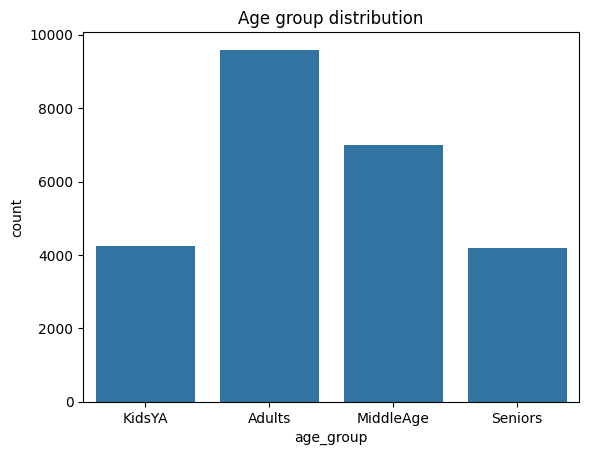

In [ ]:
#age group distribution
sns.countplot(x="age_group",data=df)
plt.title("Age group distribution")
plt.show()

In [ ]:
df.head()

,customer_id,product_id,order_id,customer_age,gender,product_name,mrp,discount_price,category,state,...,cancellation_date,payment_method,pin_code,total_order_value,payment_status,no_of_clicks,year,month,shipping_charges,age_group
0,YSB75,BW653,479577309,28,Female,Ariel Matic Top Load Liquid Detergent,977.44,909.02,Imported,Andhra Pradesh,...,NaN,Credit,318324,909.02,Paid,29,2022,May,0,Adults
1,FUS93,XV061,634865221,47,Male,VSR Channa Dal,834.09,450.41,Branded,Telangana,...,NaN,Debit,730162,450.41,Paid,95,2021,August,0,MiddleAge
2,AJP28,GF695,113166210,63,Female,Tenali Double Horse Chana Dal,1095.20,1007.58,Branded,Gujarat,...,NaN,Debit,694091,1007.58,Paid,51,2021,October,0,Seniors
3,URC55,VM478,740539230,41,Male,Tata Tea,748.16,389.04,Imported,Maharashtra,...,NaN,Credit,211807,489.04,Pending,12,2021,August,100,Adults
4,ZOP23,XD230,156544145,22,Female,VSR Channa Dal,1249.04,911.80,Local,Gujarat,...,NaN,Credit,78304,1011.8,Paid,26,2023,December,100,KidsYA


In [ ]:
df["total_order_value"].dtype

dtype('O')

In [ ]:
df["total_order_value"] = pd.to_numeric(df["total_order_value"],errors="coerce")

In [ ]:
df["total_order_value"].dtype

dtype('float64')

In [ ]:
df["total_order_value"].isna().sum()

np.int64(3134)

In [ ]:
#Top spending groups

age_spend = df.groupby("age_group")["total_order_value"].sum()
age_spend = age_spend.reset_index()
age_spend

/tmp/ipython-input-17-7012301.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby("age_group")["total_order_value"].sum()


,age_group,total_order_value
0,KidsYA,2857991.02
1,Adults,6531575.89
2,MiddleAge,4754661.07
3,Seniors,2809881.35


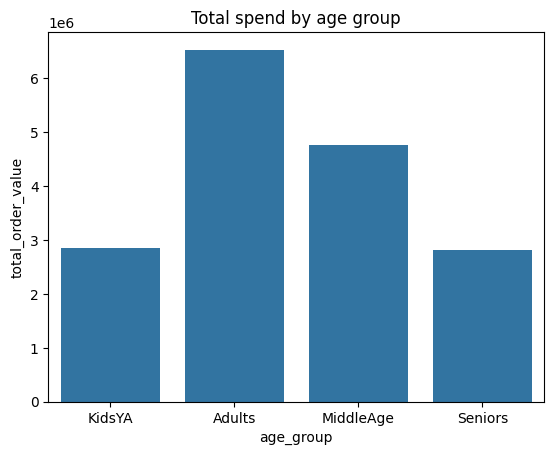

In [ ]:
sns.barplot(x="age_group",y="total_order_value",data=age_spend)
plt.title("Total spend by age group")
plt.show()

In [ ]:
#total spending for different genders
gender_spend = df.groupby("gender")["total_order_value"].sum()
gender_spend=gender_spend.reset_index()
gender_spend

,gender,total_order_value
0,Female,7265368.77
1,Male,9688740.56


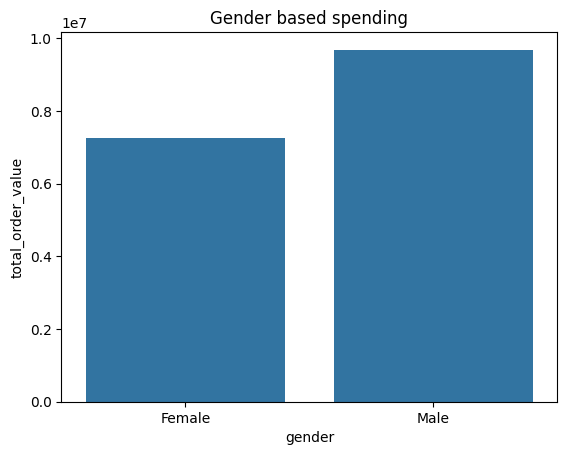

In [ ]:
sns.barplot(x="gender",y="total_order_value",data=gender_spend)
plt.title("Gender based spending")
plt.show()

In [ ]:
df['orderdate'].dtype

dtype('O')

In [ ]:
df['orderdate']=pd.to_datetime(df['orderdate'],dayfirst=True)

In [ ]:
#RFM segmentation

latest_date = df['orderdate'].max()
recency = df.groupby('customer_id')['orderdate'].max().apply(lambda x: (latest_date-x).days)

In [ ]:
frequency = df.groupby('customer_id')['order_id'].count()
monetary= df.groupby('customer_id')['total_order_value'].sum()

In [ ]:
rfm = pd.DataFrame({'Recency':recency,'Frequency':frequency,'Monetary':monetary})
rfm

,Recency,Frequency,Monetary
customer_id,,,
AAA09,489,1,0.00
AAA12,502,1,545.75
AAA79,981,1,0.00
AAB58,488,1,895.55
AAC08,482,1,690.90
...,...,...,...
ZZY23,756,1,105.66
ZZY44,440,1,850.61
ZZZ12,407,1,122.44


In [ ]:
rfm['R']=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F']=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M']=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

rfm['RFM_score'] = rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_score
customer_id,,,,,,,
AAA09,489,1,0.00,3,1,1,311
AAA12,502,1,545.75,3,1,2,312
AAA79,981,1,0.00,1,1,1,111
AAB58,488,1,895.55,3,1,3,313
AAC08,482,1,690.90,3,1,3,313


In [ ]:
df.head()

,customer_id,product_id,order_id,customer_age,gender,product_name,mrp,discount_price,category,state,...,cancellation_date,payment_method,pin_code,total_order_value,payment_status,no_of_clicks,year,month,shipping_charges,age_group
0,YSB75,BW653,479577309,28,Female,Ariel Matic Top Load Liquid Detergent,977.44,909.02,Imported,Andhra Pradesh,...,NaN,Credit,318324,909.02,Paid,29,2022,May,0,Adults
1,FUS93,XV061,634865221,47,Male,VSR Channa Dal,834.09,450.41,Branded,Telangana,...,NaN,Debit,730162,450.41,Paid,95,2021,August,0,MiddleAge
2,AJP28,GF695,113166210,63,Female,Tenali Double Horse Chana Dal,1095.20,1007.58,Branded,Gujarat,...,NaN,Debit,694091,1007.58,Paid,51,2021,October,0,Seniors
3,URC55,VM478,740539230,41,Male,Tata Tea,748.16,389.04,Imported,Maharashtra,...,NaN,Credit,211807,489.04,Pending,12,2021,August,100,Adults
4,ZOP23,XD230,156544145,22,Female,VSR Channa Dal,1249.04,911.80,Local,Gujarat,...,NaN,Credit,78304,1011.80,Paid,26,2023,December,100,KidsYA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              25000 non-null  object        
 1   product_id               25000 non-null  object        
 2   order_id                 25000 non-null  int64         
 3   customer_age             25000 non-null  int64         
 4   gender                   25000 non-null  object        
 5   product_name             25000 non-null  object        
 6   mrp                      25000 non-null  float64       
 7   discount_price           25000 non-null  float64       
 8   category                 25000 non-null  object        
 9   state                    25000 non-null  object        
 10  city                     25000 non-null  object        
 11  subscription             25000 non-null  object        
 12  bill_number              25000 n

In [ ]:
#monthly sales
monthly_orders = df.groupby(['year','month'])["total_order_value"].sum().reset_index()
monthly_orders

,year,month,total_order_value
0,2021,April,466983.55
1,2021,August,495260.02
2,2021,December,455027.34
3,2021,February,408273.45
4,2021,January,450818.55
5,2021,July,487640.18
6,2021,June,432757.23
7,2021,March,462025.11
8,2021,May,461050.08
9,2021,November,509504.80


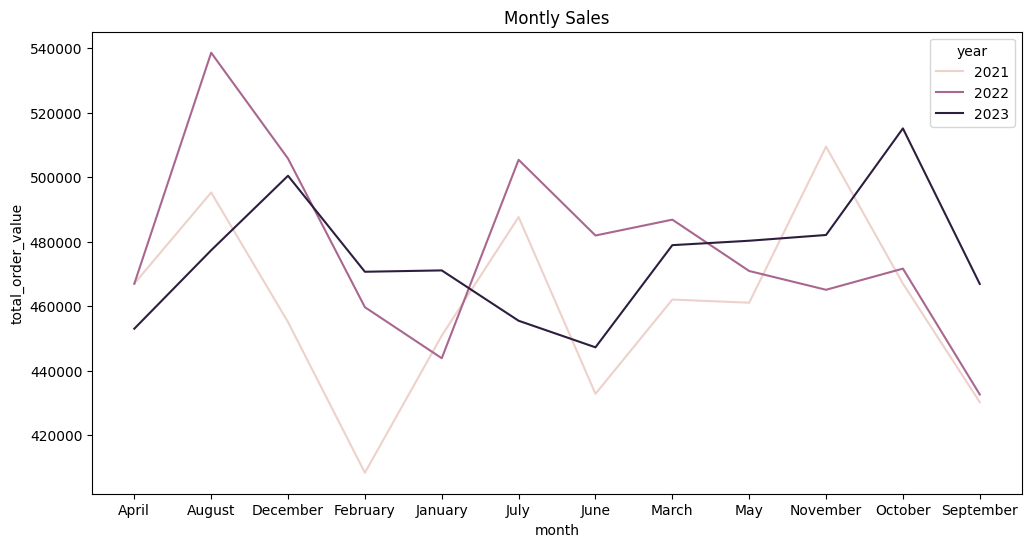

In [ ]:
#line chart to see the trend
plt.figure(figsize=(12,6))
sns.lineplot(x='month',y='total_order_value',hue='year',data=monthly_orders)
plt.title("Montly Sales")
plt.show()

In [ ]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['month'] = pd.Categorical(df['month'],categories=month_order,ordered=True)
df = df.sort_values('month')

/tmp/ipython-input-33-3124473001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_orders = df.groupby(['year','month'])["total_order_value"].sum().reset_index()


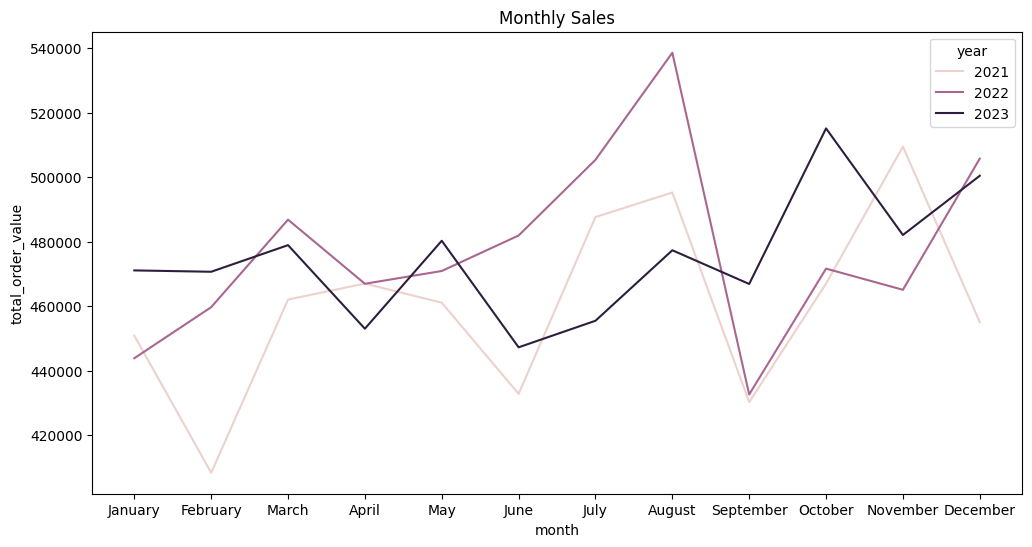

In [ ]:
#line chart to see the trend
monthly_orders = df.groupby(['year','month'])["total_order_value"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='month',y='total_order_value',hue='year',data=monthly_orders)
plt.title("Monthly Sales")
plt.show()

In [ ]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges', 'age_group'],
      dtype='object')

In [ ]:
df['order_status'].unique()

array(['Delivered', 'Returned', 'Shipped', 'Cancelled'], dtype=object)

In [ ]:
#cancellation rate

cancelled = df[df["order_status"]=='Cancelled']

cancel_rate = len(cancelled)/len(df)*100

print(f'The cancellation rate is {round(cancel_rate,2)}%')



The cancellation rate is 7.14%


In [ ]:
len(cancelled)

1784

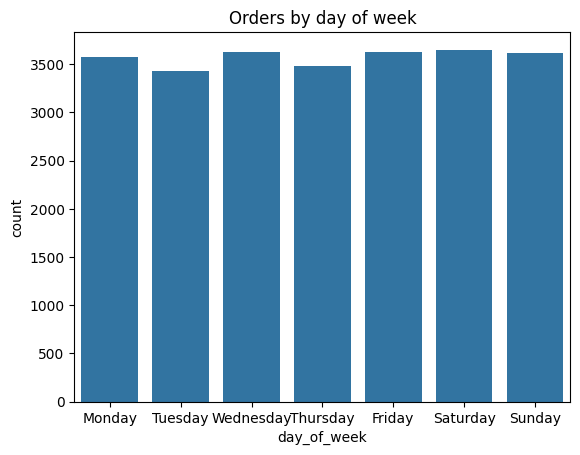

In [ ]:
# Day wise orders
df['day_of_week'] =df['orderdate'].dt.day_name()
sns.countplot(x='day_of_week',data=df,order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Orders by day of week")
plt.show()

In [ ]:
df['shipping_charges']=pd.to_numeric(df["shipping_charges"],errors='coerce')

In [ ]:
#shipping fee impact
df["ship_feeimpact"] =df['shipping_charges'].apply(lambda x:'Free Shipping' if x==0 else 'Paid Shipping')


In [ ]:
df['ship_feeimpact'].value_counts()

,count
ship_feeimpact,
Free Shipping,13149
Paid Shipping,11851


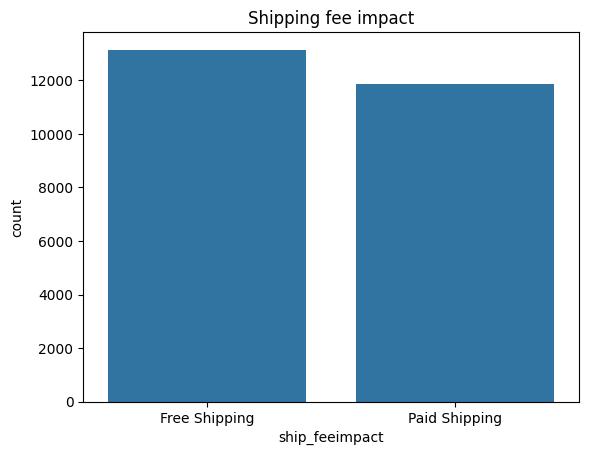

In [ ]:
sns.countplot(x='ship_feeimpact',data=df)
plt.title("Shipping fee impact")
plt.show()

<Axes: xlabel='shipping_charges', ylabel='Count'>

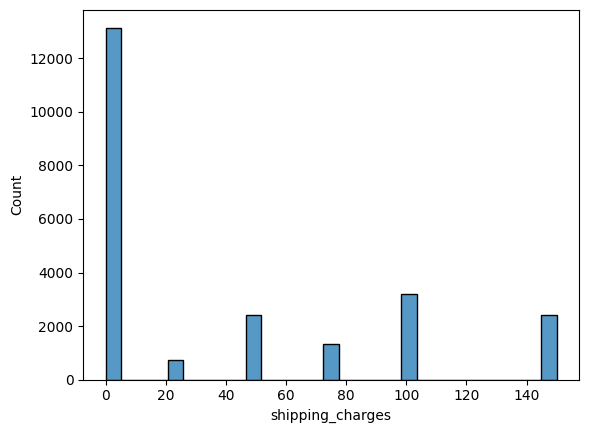

In [ ]:
sns.histplot(df["shipping_charges"])

In [ ]:
df["shipping_charges"].dtype

dtype('float64')

In [ ]:
df["city"].nunique()

40

In [ ]:
#orders per city (top cities)

top_cities = df['city'].value_counts().head(10)

In [ ]:
top_cities

,count
city,
Vadodara,679
Navi Mumbai,678
Guntur,678
Suryapet,669
Visakhapatnam,657
Rajahmundry,648
Bharuch,648
Thane,645
Aurangabad,643


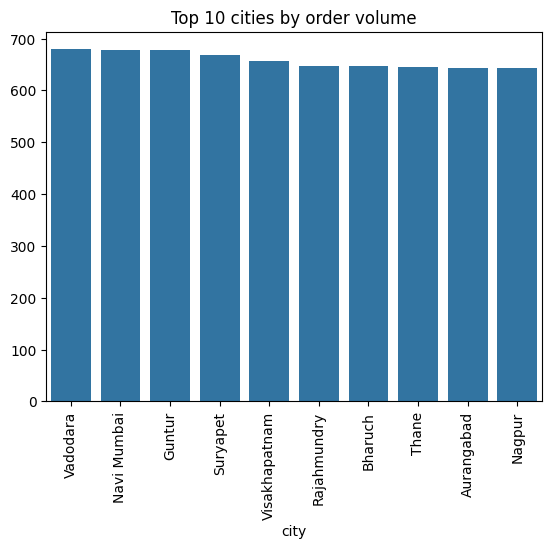

In [ ]:
sns.barplot(x=top_cities.index,y=top_cities.values)
plt.title("Top 10 cities by order volume")
plt.xticks(rotation=90)
plt.show()

In [ ]:
df['category'].unique()

array(['Imported', 'Local', 'Branded'], dtype=object)

In [ ]:
#category dominance
df['category'].value_counts()

,count
category,
Local,12402
Branded,7564
Imported,5034


In [ ]:
# Average spending for every category
local_p = df[df['category']=='Local']['total_order_value'].mean()
nonlocal_p = df[df['category']!='Local']['total_order_value'].mean()
print(f'The avg local spending is {round(local_p,2)} and for nonlocal the avg spending is {round(nonlocal_p,2)}')

The avg local spending is 780.17 and for nonlocal the avg spending is 770.61


In [ ]:
# top products
top_products = df['product_name'].value_counts().head(10)

In [ ]:
top_products

,count
product_name,
Parle Nutricrunch Digestive Cookies,1212
Harpic Bathroom Cleaner - Floral,1205
Wagh Bakri Masala Tea,1193
Tata Sampann Moong Dal (Pesara Pappu),1186
Tata Tea Chakra Gold Premium Tea,1168
Nutri Delite Breakfast Cereal,1166
Cavin's Chocolate Milkshake,1165
Ariel Matic Top Load Liquid Detergent,1145
Nimyle Herbal Anti-Bacterial Floor Cleaner,1143


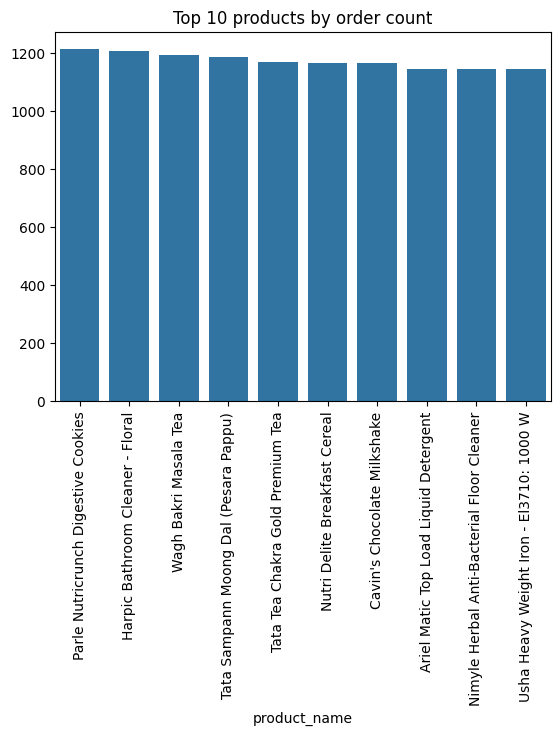

In [ ]:
sns.barplot(x=top_products.index,y=top_products.values)
plt.title("Top 10 products by order count")
plt.xticks(rotation=90)
plt.show()

In [ ]:
#conversion_rate
#high mrp,low discount

df['discount%']=(df['mrp']-df['discount_price'])/df['mrp']*100
#all rows with high mrp(top 10%) and low discount(less than 10%)
hmld = df[(df['mrp']>df['mrp'].quantile(0.9)) & (df['discount%']<10)]
conversion_rate = len(hmld[hmld['order_status']=="Delivered"])/len(hmld)*100
print(f"The coversion rate is {round(conversion_rate,0)}%")

The coversion rate is 50.0%


In [ ]:
#category wise discount percentage
cat_discount = df.groupby('category')['discount%'].mean().reset_index()
cat_discount

,category,discount%
0,Branded,27.355779
1,Imported,27.570921
2,Local,27.447191


In [ ]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges', 'age_group', 'day_of_week', 'ship_feeimpact',
       'discount%'],
      dtype='object')

In [ ]:
df['payment_method'].unique()

array(['COD', 'Debit', 'Credit', 'UPI', 'Netbanking', 'Cancelled'],
      dtype=object)

In [ ]:
#cash vs digital
digital = df[df['payment_method'].isin(['Debit', 'Credit', 'UPI', 'Netbanking'])]
cod = df[df['payment_method']=="COD"]

print(f"Digital avg order value: {digital['total_order_value'].mean()}, Cod : {cod['total_order_value'].mean()}")

Digital avg order value: 775.8547950878883, Cod : 766.1076385104451


In [ ]:
len(digital)

22052

In [ ]:
len(cod)

1164

In [ ]:
# Revenue concentration
customer_rev = df.groupby('customer_id')['total_order_value'].sum().sort_values(ascending=False)
customer_rev

,total_order_value
customer_id,
PLB80,3389.27
OYU88,3133.41
KVO58,3022.27
DKI77,2961.66
MQC85,2928.17
...,...
QXL97,0.00
QXO99,0.00
QXS29,0.00


In [ ]:
top_10p = int(0.1 *len(customer_rev))

In [ ]:
top_10p

2481

In [ ]:
rev_top10 = customer_rev.head(top_10p).sum()/customer_rev.sum()*100
print(f"Top 10% customers contribute {round(rev_top10,0)}% of revenue")

Top 10% customers contribute 23.0% of revenue


In [ ]:
df.columns

Index(['customer_id', 'product_id', 'order_id', 'customer_age', 'gender',
       'product_name', 'mrp', 'discount_price', 'category', 'state', 'city',
       'subscription', 'bill_number', 'time_spent_on_website', 'rating',
       'marketing/advertisement', 'ship_mode', 'order_status', 'orderdate',
       'delivery_date', 'cancellation_date', 'payment_method', 'pin_code',
       'total_order_value', 'payment_status', 'no_of_clicks', 'year', 'month',
       'shipping_charges', 'age_group', 'day_of_week', 'ship_feeimpact',
       'discount%'],
      dtype='object')

In [ ]:
df['marketing/advertisement'].unique()

array(['Facebook', 'Instagram', 'TV', 'Other', 'Friends'], dtype=object)

In [ ]:
# Social media impacts
roi = df.groupby('marketing/advertisement')['total_order_value'].mean().sort_values(ascending=False)
print(roi)

marketing/advertisement
Other        793.302705
Facebook     774.806972
Instagram    772.407276
TV           769.500072
Friends      767.714544
Name: total_order_value, dtype: float64


In [ ]:
# marketing reach
traffic = df['marketing/advertisement'].value_counts()
delivered = df[df['order_status']=='Delivered']['marketing/advertisement'].value_counts()
delivered

,count
marketing/advertisement,
Instagram,4404
Facebook,3264
Friends,2148
Other,2099
TV,1094
